## Install Packages for the Environment via Anaconda

Follow these steps to install new packages:

1. **Activate the Environment**  
   After creating the environment, activate it using:  
   **`conda activate ErSE222`**

2. **Install torchbnn**  
   Once the environment is activated, install torchvision with:  
   **`pip install torchbnn`**  
   *Usage*: torchbnn is a lightweight library designed for building Bayesian neural networks using PyTorch.

# UQ with PyTorch

$f(x)=sin(x)$. 


Given enough pairs $(x,f(x))$ we wish the network to be able to give us a correct estimate of $f(x_i)$ on an unseen $x_i$.

In this tutorial we will implement 3 of such techniques, namely:

- UQ by MC-Dropout;
- UQ by Deep Ensembles;
- UQ by Bayesian Neural Networks.



In [1]:
%matplotlib inline

import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.distributions as dd
import torchbnn as bnn

from torch.utils.data import TensorDataset, DataLoader 


KeyboardInterrupt



In [ ]:
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled   = False

    return True

## Create dataset

In [ ]:
set_seed(5)

In [ ]:
ntrain = 64*8
ntest = 1000
sigma = 0.1 # noise standard deviation

xtrain = torch.rand(ntrain) * 10 - 6.5
xtest = torch.linspace(-6.5, 9., ntest)
noise = sigma * torch.randn(xtrain.shape[0])

ytrain = torch.sin(xtrain) + noise
ytest = torch.sin(xtest)

plt.figure()
plt.plot(xtest, ytest, 'k')
plt.plot(xtrain, ytrain, '.r')
plt.plot(xtest, ytest+2.5*sigma, '--r')
plt.plot(xtest, ytest-2.5*sigma, '--r')
plt.title('Data');

In [6]:
train_dataset = TensorDataset(xtrain, ytrain)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [7]:
ypreds, ystds = {}, {}

## Deterministic Network

In [8]:
class DeepNetwork(nn.Module):
    def __init__(self, I, H, O, drop=0.3):
        super(DeepNetwork, self).__init__()
        self.net =  nn.Sequential(
            nn.Linear(I, H[0], bias=True),
            nn.ReLU(),
            nn.Linear(H[0], H[1], bias=True),
            nn.ReLU(),
            nn.Linear(H[1], O, bias=True))
        
    def forward(self, x):
        return self.net(x)

In [9]:
model = DeepNetwork(1, [20, 50], 1)
model

DeepNetwork(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=1, bias=True)
  )
)

Epoch: 0, Loss: 0.060261675622314215
Epoch: 500, Loss: 0.001860625867266208
Epoch: 1000, Loss: 0.0013623117847600952
Epoch: 1500, Loss: 0.0013027651875745505
Epoch: 2000, Loss: 0.0011993348743999377
Epoch: 2500, Loss: 0.0012757467338815331
Epoch: 3000, Loss: 0.0011893166811205447
Epoch: 3500, Loss: 0.0012312325634411536
Epoch: 4000, Loss: 0.0013531211006920785
Epoch: 4500, Loss: 0.001225236672325991


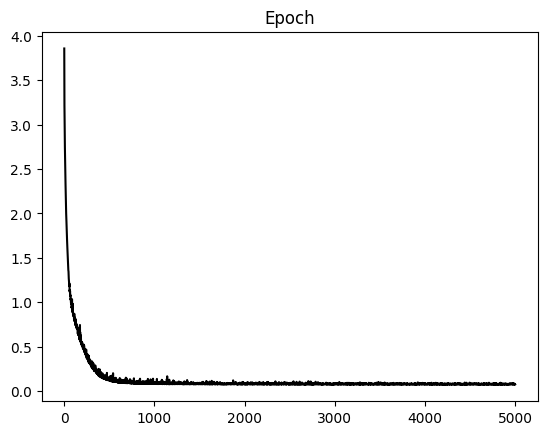

In [10]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = torch.nn.MSELoss()
n_epochs = 5000

model.train()
loss_hist = []
for epoch in range(n_epochs):
    total_loss = 0.
    for X, y in train_loader:
        optimizer.zero_grad()
        yest = model(X.view(X.shape[0], 1)).squeeze()
        loss = criterion(yest, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_hist.append(total_loss)
    if epoch % (n_epochs//10) == 0:
        print(f'''Epoch: {epoch}, Loss: {total_loss / X.size(0)}''')
        
plt.figure()
plt.plot(loss_hist, 'k')
plt.title('Epoch');

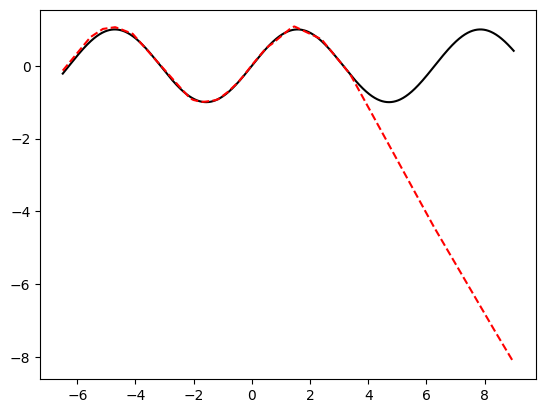

In [12]:
# Prediction
ypred = model(xtest.view(xtest.shape[0], 1)) 
ypreds['Deterministic'] = ypred

plt.figure()
plt.plot(xtest, ytest, 'k')
plt.plot(xtest, ypred.detach().numpy(), '--r');

## Network with Dropout UQ

In [13]:
class DeepDropNetwork(nn.Module):
    def __init__(self, I, H, O, drop=0.3):
        super(DeepDropNetwork, self).__init__()
        self.net =  nn.Sequential(
            nn.Linear(I, H[0], bias=True),
            nn.Dropout(p=drop),
            nn.ReLU(),
            nn.Linear(H[0], H[1], bias=True),
            nn.Dropout(p=drop),
            nn.ReLU(),
            nn.Linear(H[1], O, bias=True))
        
    def forward(self, x):
        return self.net(x)

In [14]:
model = DeepDropNetwork(1, [20, 50], 1, drop=0.1)
model

DeepDropNetwork(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): Dropout(p=0.1, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=20, out_features=50, bias=True)
    (4): Dropout(p=0.1, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=1, bias=True)
  )
)

Epoch: 0, Loss: 0.054319760762155056
Epoch: 500, Loss: 0.00879590620752424
Epoch: 1000, Loss: 0.007785276568029076
Epoch: 1500, Loss: 0.005518427264178172
Epoch: 2000, Loss: 0.0062291392823681235
Epoch: 2500, Loss: 0.005632260028505698
Epoch: 3000, Loss: 0.004958972771419212
Epoch: 3500, Loss: 0.004239128000335768
Epoch: 4000, Loss: 0.0043196253827773035
Epoch: 4500, Loss: 0.004022855981020257


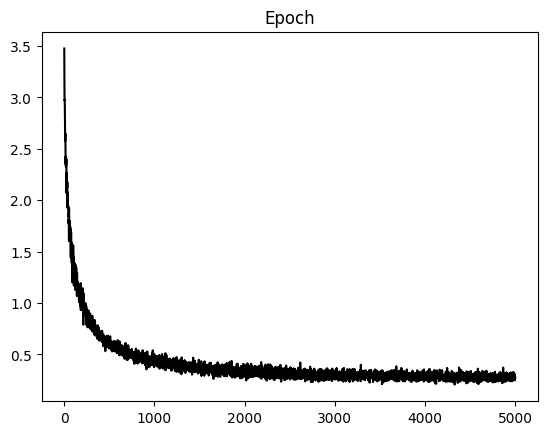

In [15]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = torch.nn.MSELoss()
n_epochs = 5000

model.train()
loss_hist = []
for epoch in range(n_epochs):
    total_loss = 0.
    for X, y in train_loader:
        optimizer.zero_grad()
        yest = model(X.view(X.shape[0], 1)).squeeze() 
        loss = criterion(yest, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_hist.append(total_loss)
    if epoch % (n_epochs//10) == 0:
        print(f'''Epoch: {epoch}, Loss: {total_loss / X.size(0)}''')

plt.figure()
plt.plot(loss_hist, 'k')
plt.title('Epoch');

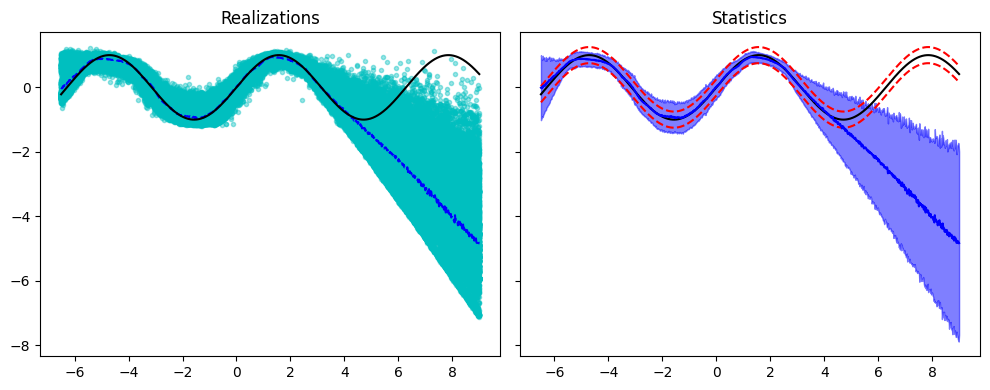

In [16]:
nreals = 400
yreals = np.hstack([model(xtest.view(xtest.shape[0], 1)).detach().numpy() for _ in range(nreals)])

ypred = yreals.mean(axis=1)
ystd = yreals.std(axis=1)
ypreds['Dropout'] = ypred
ystds['Dropout'] = ystd

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
axs[0].plot(xtest, yreals, '.c', alpha=0.4)
axs[0].plot(xtest, ypred, '--b')
axs[0].plot(xtest, ytest, 'k')
axs[0].set_title('Realizations')
axs[1].plot(xtest, ytest, 'k')
axs[1].plot(xtest, ytest+2.5*sigma, '--r')
axs[1].plot(xtest, ytest-2.5*sigma, '--r')
axs[1].plot(xtest, ypred, 'b')
axs[1].fill_between(xtest, ypred - 2.5*ystd, ypred + 2.5*ystd,
                    alpha=0.5, color='b')
axs[1].set_title('Statistics')
fig.tight_layout();

## Deep Ensemble Network UQ

Training model 0/10
Epoch: 0, Loss: 0.05670451372861862
Epoch: 200, Loss: 0.009451875404920429
Epoch: 400, Loss: 0.004401143989525735
Epoch: 600, Loss: 0.0024544036568840966
Epoch: 800, Loss: 0.0017971699126064777
Epoch: 1000, Loss: 0.0015350560570368543
Epoch: 1200, Loss: 0.0013468808319885284
Epoch: 1400, Loss: 0.0013451561680994928
Epoch: 1600, Loss: 0.0012826974707422778
Epoch: 1800, Loss: 0.0013627844164147973
Training model 1/10
Epoch: 0, Loss: 0.057241424918174744
Epoch: 200, Loss: 0.009375072666443884
Epoch: 400, Loss: 0.00356428962550126
Epoch: 600, Loss: 0.0018867067847168073
Epoch: 800, Loss: 0.0014602379087591544
Epoch: 1000, Loss: 0.0013569448346970603
Epoch: 1200, Loss: 0.001251237394171767
Epoch: 1400, Loss: 0.0012109639137634076
Epoch: 1600, Loss: 0.0012198245676700026
Epoch: 1800, Loss: 0.001210686117701698
Training model 2/10
Epoch: 0, Loss: 0.05605358723551035
Epoch: 200, Loss: 0.009029433655086905
Epoch: 400, Loss: 0.0024804476997815073
Epoch: 600, Loss: 0.001599855

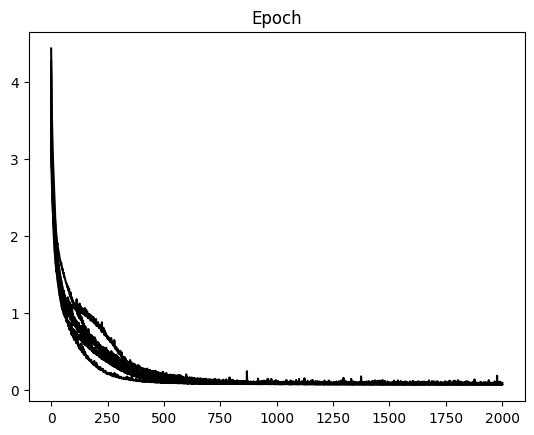

In [17]:
criterion = torch.nn.MSELoss()
n_epochs = 2000
n_models = 10

models = []
loss_hists = []
for i in range(n_models):
    print(f'Training model {i}/{n_models}')
    model = DeepNetwork(1, [20, 50], 1)
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

    model.train()
    loss_hist = []
    for epoch in range(n_epochs):
        total_loss = 0.
        for X, y in train_loader:
            optimizer.zero_grad()
            yest = model(X.view(X.shape[0], 1)).squeeze()
            loss = criterion(yest, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_hist.append(total_loss)
        if epoch % (n_epochs//10) == 0:
            print(f'Epoch: {epoch}, Loss: {total_loss / X.size(0)}')
    loss_hists.append(loss_hist)
    models.append(model)
    
plt.figure()
plt.plot(np.array(loss_hists).T, 'k')
plt.title('Epoch');

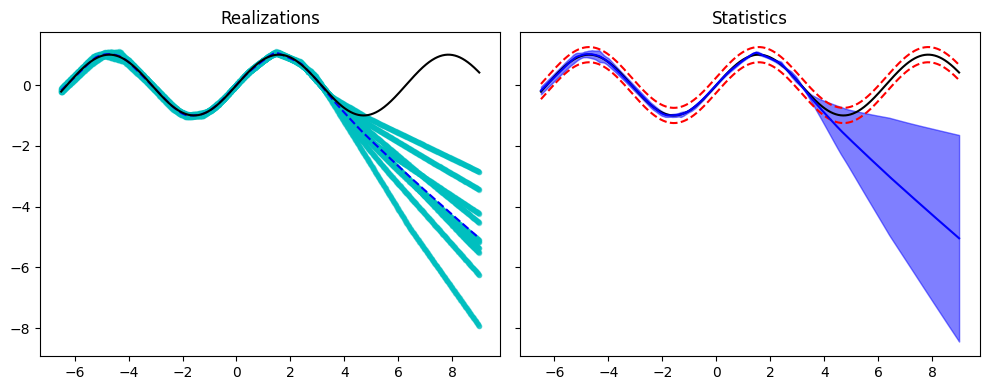

In [18]:
# Prediction
yreals = np.hstack([model(xtest.view(xtest.shape[0], 1)).detach().numpy() for model in models])

ypred = yreals.mean(axis=1)
ystd = yreals.std(axis=1)
ypreds['Ensemble'] = ypred
ystds['Ensemble'] = ystd

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
axs[0].plot(xtest, yreals, '.c', alpha=0.4)
axs[0].plot(xtest, ypred, '--b')
axs[0].plot(xtest, ytest, 'k')
axs[0].set_title('Realizations')
axs[1].plot(xtest, ytest, 'k')
axs[1].plot(xtest, ytest+2.5*sigma, '--r')
axs[1].plot(xtest, ytest-2.5*sigma, '--r')
axs[1].plot(xtest, ypred, 'b')
axs[1].fill_between(xtest, ypred - 2.5*ystd, ypred + 2.5*ystd,
                    alpha=0.5, color='b')
axs[1].set_title('Statistics')
fig.tight_layout();


## Bayesian Network

In [19]:
class BayesianNetwork(nn.Module):
    def __init__(self, I, H, O):
        super(BayesianNetwork, self).__init__()
        self.net =  nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=I, out_features=H[0]),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=H[0], out_features=H[1]),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=H[1], out_features=O))
        
    def forward(self, x):
        return self.net(x)

In [20]:
model = BayesianNetwork(1, [20, 50], 1)
model

BayesianNetwork(
  (net): Sequential(
    (0): BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=1, out_features=20, bias=True)
    (1): ReLU()
    (2): BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=20, out_features=50, bias=True)
    (3): ReLU()
    (4): BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=50, out_features=1, bias=True)
  )
)

Epoch: 0, Loss: 0.5732439160346985, MSE: 0.5600411891937256, KL: 1.3202745914459229
Epoch: 500, Loss: 0.09510169178247452, MSE: 0.07929180562496185, KL: 1.5809884071350098
Epoch: 1000, Loss: 0.07455076277256012, MSE: 0.05978256091475487, KL: 1.4768203496932983
Epoch: 1500, Loss: 0.04831160604953766, MSE: 0.03313358128070831, KL: 1.5178027153015137
Epoch: 2000, Loss: 0.03400714695453644, MSE: 0.020040884613990784, KL: 1.3966261148452759
Epoch: 2500, Loss: 0.026432909071445465, MSE: 0.013642344623804092, KL: 1.2790565490722656
Epoch: 3000, Loss: 0.026419173926115036, MSE: 0.01444656029343605, KL: 1.1972614526748657
Epoch: 3500, Loss: 0.023654505610466003, MSE: 0.012368264608085155, KL: 1.1286240816116333
Epoch: 4000, Loss: 0.022151976823806763, MSE: 0.011305703781545162, KL: 1.084627389907837
Epoch: 4500, Loss: 0.021565696224570274, MSE: 0.010934918187558651, KL: 1.0630778074264526


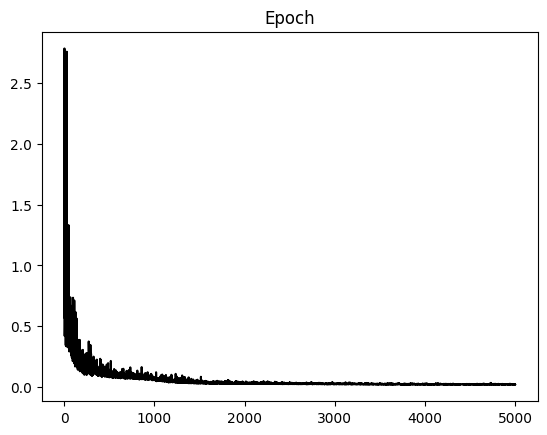

In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
mse_loss = nn.MSELoss()
kl_loss = bnn.BKLLoss(reduction='mean', last_layer_only=False)
kl_weight = 0.01
n_epochs = 5000

model.train()
loss_hist = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    yest = model(xtrain.view(xtrain.shape[0], 1)).squeeze() 
    mse = mse_loss(yest, ytrain)
    kl = kl_loss(model)
    loss = mse + kl_weight*kl
    loss.backward()
    optimizer.step()
    loss_hist.append(loss.item())
    
    if epoch % (n_epochs//10) == 0:
        print(f'''Epoch: {epoch}, Loss: {loss.item()}, MSE: {mse.item()}, KL: {kl.item()}''')

plt.figure()
plt.plot(loss_hist, 'k')
plt.title('Epoch');

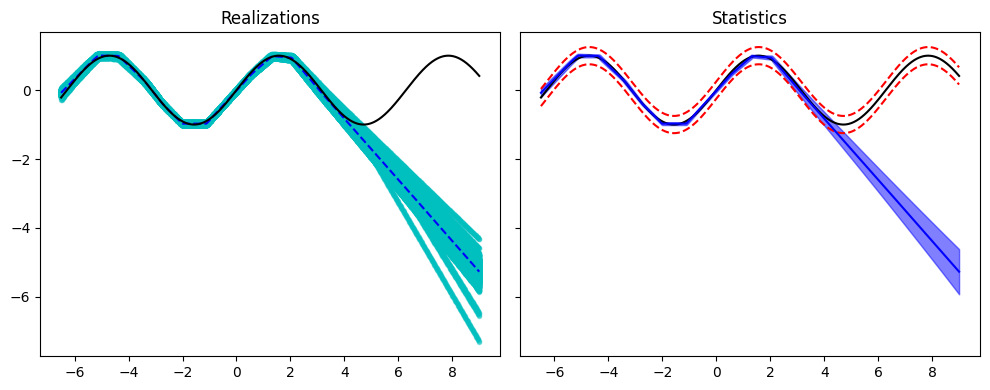

In [22]:
# Prediction
nreals = 400
yreals = np.hstack([model(xtest.view(xtest.shape[0], 1)).detach().numpy() for _ in range(nreals)])

ypred = yreals.mean(axis=1)
ystd = yreals.std(axis=1)
ypreds['BayesianNN'] = ypred
ystds['BayesianNN'] = ystd

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
axs[0].plot(xtest, yreals, '.c', alpha=0.4)
axs[0].plot(xtest, ypred, '--b')
axs[0].plot(xtest, ytest, 'k')
axs[0].set_title('Realizations')
axs[1].plot(xtest, ytest, 'k')
axs[1].plot(xtest, ytest+2.5*sigma, '--r')
axs[1].plot(xtest, ytest-2.5*sigma, '--r')
axs[1].plot(xtest, ypred, 'b')
axs[1].fill_between(xtest.squeeze(), ypred - 2.5*ystd, ypred + 2.5*ystd,
                    alpha=0.5, color='b')
axs[1].set_title('Statistics')
fig.tight_layout();

Finally, let's compare the different predictions (and their uncertainties)

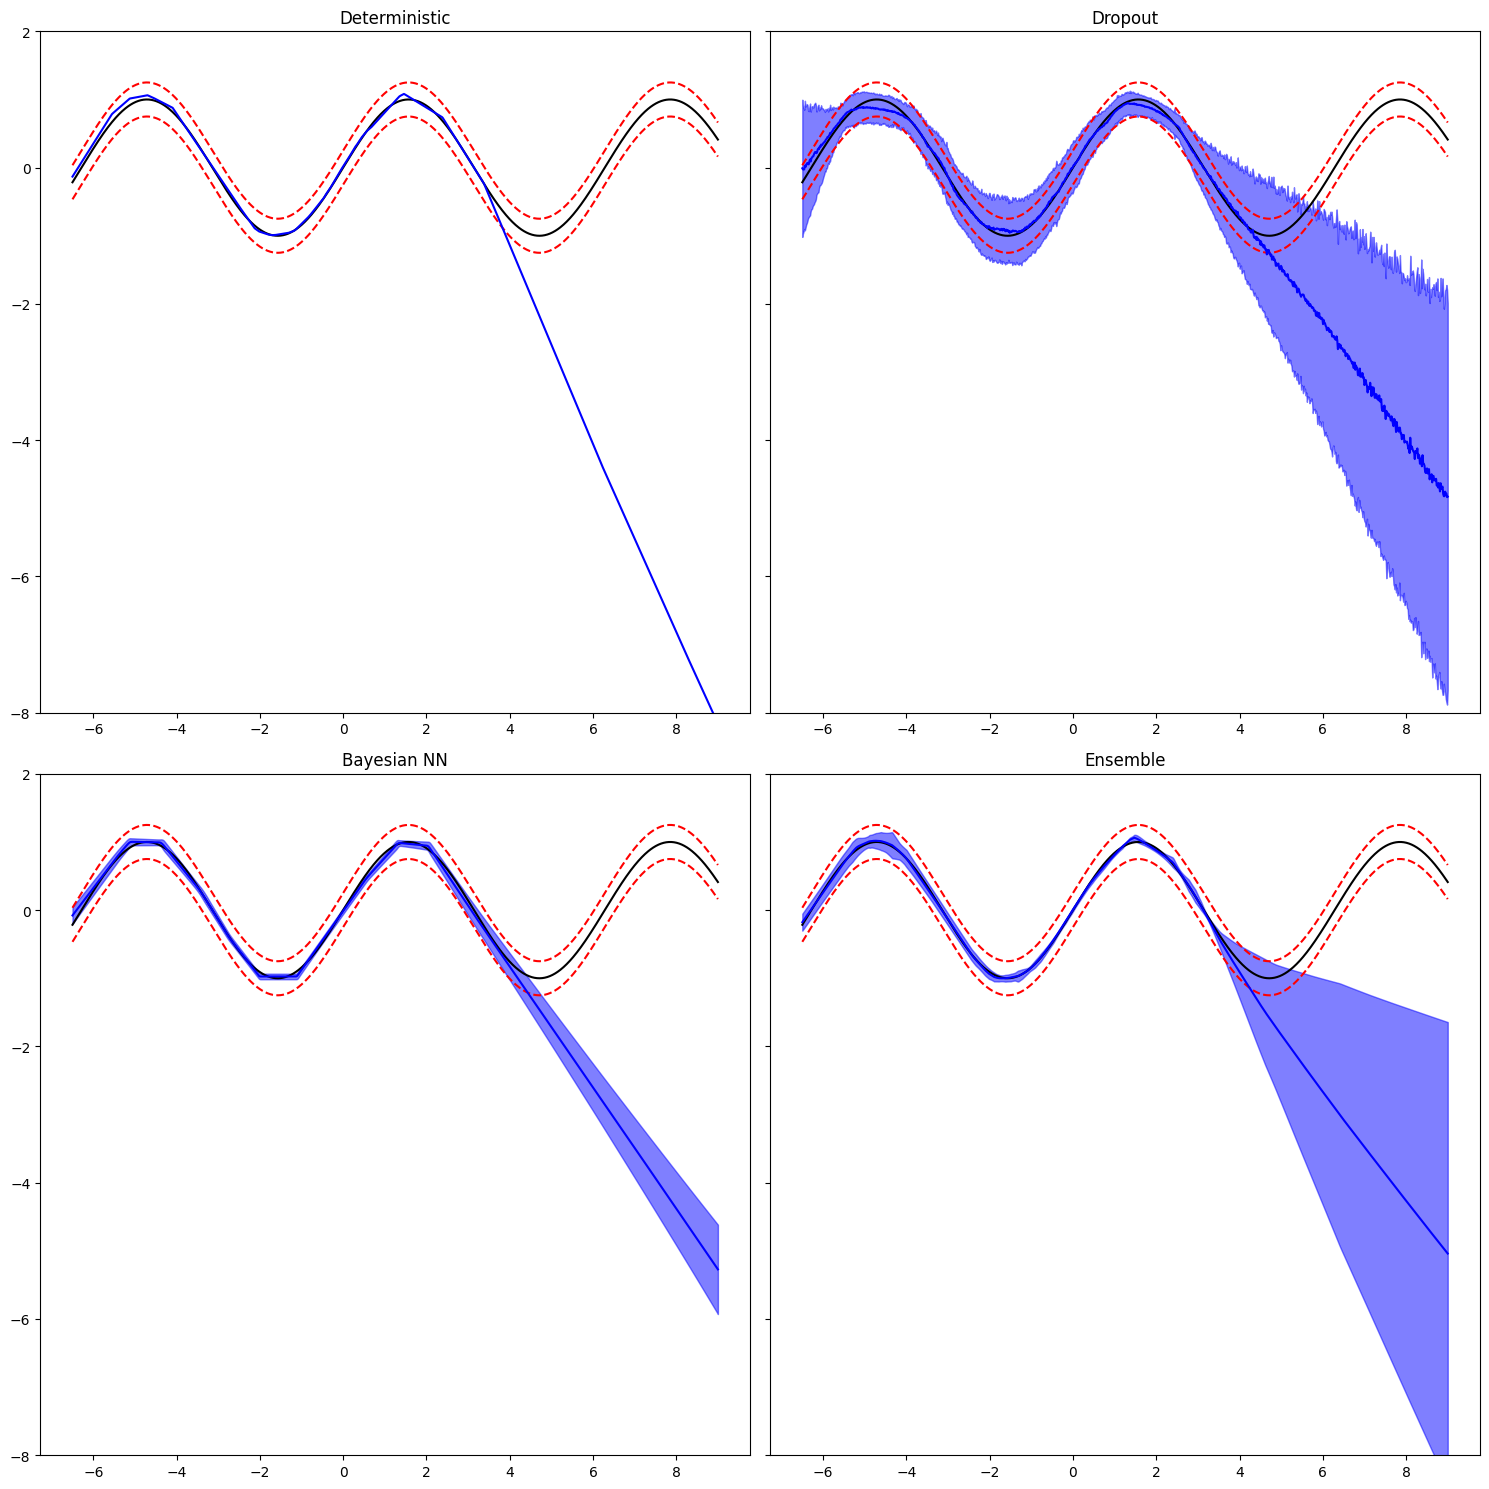

In [23]:
fig, axs = plt.subplots(2, 2, sharey=True, figsize=(15, 15))
axs[0][0].plot(xtest, ytest, 'k')
axs[0][0].plot(xtest, ytest+2.5*sigma, '--r')
axs[0][0].plot(xtest, ytest-2.5*sigma, '--r')
axs[0][0].plot(xtest, ypreds['Deterministic'].detach().numpy(), 'b')
axs[0][0].set_title('Deterministic')
axs[0][1].plot(xtest, ytest, 'k')
axs[0][1].plot(xtest, ytest+2.5*sigma, '--r')
axs[0][1].plot(xtest, ytest-2.5*sigma, '--r')
axs[0][1].plot(xtest, ypreds['Dropout'], 'b')
axs[0][1].fill_between(xtest, ypreds['Dropout'] - 2.5*ystds['Dropout'], 
                       ypreds['Dropout'] + 2.5*ystds['Dropout'],
                       alpha=0.5, color='b')
axs[0][1].set_title('Dropout')
axs[1][1].plot(xtest, ytest, 'k')
axs[1][1].plot(xtest, ytest+2.5*sigma, '--r')
axs[1][1].plot(xtest, ytest-2.5*sigma, '--r')
axs[1][1].plot(xtest, ypreds['Ensemble'], 'b')
axs[1][1].fill_between(xtest, ypreds['Ensemble'] - 2.5*ystds['Ensemble'], 
                       ypreds['Ensemble'] + 2.5*ystds['Ensemble'],
                       alpha=0.5, color='b')
axs[1][1].set_title('Ensemble')
axs[1][0].plot(xtest, ytest, 'k')
axs[1][0].plot(xtest, ytest+2.5*sigma, '--r')
axs[1][0].plot(xtest, ytest-2.5*sigma, '--r')
axs[1][0].plot(xtest, ypreds['BayesianNN'], 'b')
axs[1][0].fill_between(xtest, ypreds['BayesianNN'] - 2.5*ystds['BayesianNN'], 
                       ypreds['BayesianNN'] + 2.5*ystds['BayesianNN'],
                       alpha=0.5, color='b')
axs[1][0].set_title('Bayesian NN')
axs[0][0].set_ylim(-8, 2)
#axs[2][1].axis('off')
fig.tight_layout();